In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from icecream import ic
import seaborn as sns
from matplotlib import pyplot as plt
from typing import List, Dict, Any, Optional, Tuple, Union

In [2]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [3]:
train = pd.read_csv(r"./train.csv")
test = pd.read_csv(r"./test.csv")
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [4]:
def get_safe_n_splits(y, requested_splits=10):
    """Return the maximum n_splits that won't cause stratification issues"""
    unique_counts = pd.Series(y).value_counts()
    min_count = unique_counts.min()
    return min(requested_splits, max(2, min_count))


def target_enc_bayes_smoothing(
        x: np.ndarray, 
        y: np.ndarray,
        n_kf_splits: int,
        smoothing_factor: float, 
        noise_std: int = 0
        ) -> np.ndarray:
    """
    Applies target encoding with bayesian smoothign to selected discrete variable.

    Parameters:
    -----------
    x : np.ndarray
        Categorical variable
    y : np.ndarray
        Target variable
    n_kf_splits : int
        Number of splits for KFold cross-validation
    smoothing_factor :

    """
    kf = KFold(n_splits=n_kf_splits, shuffle=True, random_state=0xC0FFEE)
    encoded_values = np.zeros(x.shape[0])

    glob_mean = y.mean()

    for j, (train_idx, val_idx) in enumerate(kf.split(x)):
        # if i < 1:
        #     ic(train_idx)
        #     ic(val_idx)
        #     ic(x[train_idx])
        #     ic(x[val_idx])
        train_stats = {}
        
        for cat in np.unique(x[train_idx]):
            mask = x[train_idx] == cat
            cat_mean = y[train_idx][mask].mean()
            cat_count = mask.sum()

            smoothed_mean = (cat_count * cat_mean + smoothing_factor * glob_mean) / (cat_count + smoothing_factor)

            confidence = cat_count / (cat_count + smoothing_factor)

            train_stats[cat] = {
                'enc_value': smoothed_mean,
                'conf': confidence,
                'sample_size': cat_count, 
                'raw_mean': cat_mean
            }
        # ic(train_stats)
        for i, cat in enumerate(x[val_idx]):
            # ic(cat)
            enc_val = train_stats.get(cat, {}).get('enc_value', glob_mean)

            if noise_std > 0:
                
                enc_val += np.random.normal(0, noise_std)
            
            encoded_values[val_idx[i]] = enc_val
        
    return encoded_values, train_stats


def regression_imputer(
        data: pd.DataFrame,
        x_features: List[str],
        target: str,
        model: Optional[Any] = None
        ):
    """
    Method for feature imputing
    """
    if model is None:
        model = BayesianRidge()

    # selected_features = ['Id', 'MSZoning', 'LotArea', 'LotShape', 'LandContour', 'Neighborhood', 'LotConfig', 'LotFrontage']
    # x_features = ['MSZoning', 'LotArea', 'LotShape', 'LandContour', 'Neighborhood', 'LotConfig']
    mask = data[target].isnull()

    train = data.iloc[~mask]
    # train_ids = train.Id
    test = data.iloc[mask]
    # test_ids = test.Id

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0xC0FFEE)

    model.fit(train[x_features].to_numpy(), train[target].values)

    scores = cross_val_score(
        estimator=model, 
        X=train[x_features].to_numpy(), 
        y=train[target].values, 
        cv=kf,
        n_jobs=-1)
    for i, score in enumerate(scores):
        print(f"Fold {i}: {score}")
    
    imputed_target = model.predict(test[x_features].to_numpy())

    test[target] = imputed_target

    result = pd.concat([train, test]).sort_values(by='Id')
    
    return result


def timedata_enc(
        data: pd.DataFrame,
        col: str):
    normalized_x = (data[col].values + 2*np.pi / 2) % 2*np.pi - 2*np.pi / 2
    

In [6]:
dtypes_dict = {
    'num': ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 
            'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
            '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 
            'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
            'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 
            'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
            'MiscVal', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold'],
    'cat_te': ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 
               'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 
               'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 
               'Foundation', 'Heating', 'Electrical', 'GarageType', 'SaleType',
               'SaleCondition'],
#     'ord': ['Utilities', 'LotConfig', 'LandSlope', 'ExterQual', 'ExterCond', 'BsmtQual',
#             'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'KitchenQual', 
#             'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 
#             'PavedDrive', 'PoolQC', 'Fence'],
    'ord_cat_order': {
        'Utilities': ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
        'LotConfig': ['Inside', 'Corner', 'CulDSac', 'FR2', 'FR3'],
        'LandSlope': ['Gtl', 'Mod', 'Sev'],
        'ExterQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'BsmtQual': ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'BsmtCond': ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], 
        'BsmtExposure': ['NA', 'No', 'Mn', 'Av', 'Gd'], 
        'BsmtFinType1': ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'], 
        'BsmtFinType2': ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'], 
        'HeatingQC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'], 
        'Functional': ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'], 
        'FireplaceQu': ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], 
        'GarageFinish': ['NA', 'Unf', 'RFn', 'Fin'], 
        'GarageQual': ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], 
        'GarageCond': ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], 
        'PavedDrive': ['N', 'P', 'Y'], 
        'PoolQC': ['NA', 'Fa', 'TA', 'Gd', 'Ex'], 
        'Fence': ['NA', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']
        },
    'cat_ohe': ['MiscFeature'],
    'datetime': ['MoSold'],
    'bin': ['CentralAir']
}

columns_to_fill_nan_with_NA_str = ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
                                   'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 
                                   'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

# columns_to_fill_nan_with_NA_str = []


In [7]:
# drop one row
train.dropna(subset=['Electrical'], inplace=True)
train.fillna({'GarageYrBlt': train['GarageYrBlt'].median()}, inplace=True)

# fill some columns with NA
# train['BsmtPresent'] = [1 if isinstance(i, str) else 0 for i in train['BsmtQual'].values]
for col in columns_to_fill_nan_with_NA_str:
    train.fillna({col: 'NA'}, inplace=True)

In [8]:
n_folds = get_safe_n_splits(y=train['SalePrice'])

for col in dtypes_dict['cat_te']:
    try:
        enc_col, enc_stats = target_enc_bayes_smoothing(train[col].values, train['SalePrice'].values, 5, 1, 0.05)
        train[col] = enc_col
    except Exception as e:
        # ic(col)
        raise e

In [9]:
for col, order in dtypes_dict['ord_cat_order'].items():
    ord_enc = OrdinalEncoder(categories=[order])
    enc_col = ord_enc.fit_transform(train[col].values.reshape(-1, 1))
    train[col] = enc_col.reshape(1, -1)[0]

In [10]:
train['CentralAir'] = train['CentralAir'].apply(lambda x: 1 if x=='Y' else 0)

train.drop(columns=['MoSold'], inplace=True)

In [11]:
train_ohe_enc_req = train['MiscFeature']
train_normal = train.drop(columns=['MiscFeature'])
ohe_enc = OneHotEncoder(drop='first')
train_ohe_enc = ohe_enc.fit_transform(train_ohe_enc_req.values.reshape(-1, 1)).toarray()
# FIX: Create OHE DataFrame with the same index as the original train
ohe_df = pd.DataFrame(
    train_ohe_enc, 
    columns=[f'MiscFeature{i}' for i in range(train_ohe_enc.shape[1])],
    index=train.index  # Use original train index
)
train_fin = pd.concat([
    train_normal.drop(columns=['SalePrice']).reset_index(drop=True), 
    ohe_df.reset_index(drop=True), 
    train_normal['SalePrice'].reset_index(drop=True)
    ], axis=1)

In [12]:
train_fin

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscVal,YrSold,SaleType,SaleCondition,MiscFeature0,MiscFeature1,MiscFeature2,MiscFeature3,SalePrice
0,1,244349.297247,192032.905285,65.0,8450,181958.213668,184218.367045,165008.563588,180325.016627,3.0,...,0.0,0,2008,173848.636277,175700.112962,1.0,0.0,0.0,0.0,208500
1,2,187848.544368,192032.933163,80.0,9600,181958.180796,184218.313574,165008.616001,180324.931104,3.0,...,0.0,0,2007,173848.712839,175700.005703,1.0,0.0,0.0,0.0,181500
2,3,238403.619788,189381.808509,68.0,11250,179994.733401,182216.833718,206727.195505,179348.026796,3.0,...,0.0,0,2008,171977.152229,173637.534966,1.0,0.0,0.0,0.0,223500
3,4,169129.569503,189381.850064,60.0,9550,179994.636255,182216.931293,206727.071701,179347.911819,3.0,...,0.0,0,2006,171977.114999,149403.907161,1.0,0.0,0.0,0.0,140000
4,5,244349.454434,192032.803541,84.0,14260,181958.119822,184218.252355,206938.373030,180324.929658,3.0,...,0.0,0,2008,173848.547045,175699.930026,1.0,0.0,0.0,0.0,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,1456,240740.100674,190886.695954,62.0,7917,181782.488364,183890.890694,167550.452215,181073.740080,3.0,...,0.0,0,2007,174611.581294,176285.188783,1.0,0.0,0.0,0.0,175000
1455,1457,185058.967114,190248.737775,85.0,13175,180328.265761,182709.169636,163704.269131,179806.730716,3.0,...,3.0,0,2010,173545.281484,175241.718404,1.0,0.0,0.0,0.0,210000
1456,1458,164988.156858,190886.676807,66.0,9042,181782.418876,183890.907374,167550.408177,181073.816513,3.0,...,4.0,2500,2010,174611.559002,176285.119939,0.0,0.0,1.0,0.0,266500
1457,1459,183015.438315,190886.773021,68.0,9717,181782.477335,183890.891010,167550.479000,181073.773806,3.0,...,0.0,0,2010,174611.467262,176285.236377,1.0,0.0,0.0,0.0,142125


In [13]:
train_f = regression_imputer(
    data=train_fin, 
    x_features=['MSZoning', 'LotShape', 'LandContour', 'Neighborhood', 'LotConfig'],
    target='LotFrontage',
    model=BayesianRidge()
    )

train_ff = regression_imputer(
    data=train_f,
    x_features=['MSSubClass', 'MasVnrType', 'ExterQual', 'ExterCond', 'YearBuilt', 'YearRemodAdd'],
    target='MasVnrArea',
    model=BayesianRidge()
    )

c:\Users\user\Desktop\alm_tmp\house_price_pred\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fold 0: 0.10824974462247805
Fold 1: 0.07922064043916088
Fold 2: 0.10903016416316047
Fold 3: 0.07568535486105943
Fold 4: 0.08674076627354255


c:\Users\user\Desktop\alm_tmp\house_price_pred\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fold 0: 0.3077225152173786
Fold 1: 0.4349965806962014
Fold 2: 0.30863542006188704
Fold 3: 0.311377522446625
Fold 4: 0.3318797541367128


In [14]:
train_ff

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscVal,YrSold,SaleType,SaleCondition,MiscFeature0,MiscFeature1,MiscFeature2,MiscFeature3,SalePrice
0,1,244349.297247,192032.905285,65.0,8450,181958.213668,184218.367045,165008.563588,180325.016627,3.0,...,0.0,0,2008,173848.636277,175700.112962,1.0,0.0,0.0,0.0,208500
1,2,187848.544368,192032.933163,80.0,9600,181958.180796,184218.313574,165008.616001,180324.931104,3.0,...,0.0,0,2007,173848.712839,175700.005703,1.0,0.0,0.0,0.0,181500
2,3,238403.619788,189381.808509,68.0,11250,179994.733401,182216.833718,206727.195505,179348.026796,3.0,...,0.0,0,2008,171977.152229,173637.534966,1.0,0.0,0.0,0.0,223500
3,4,169129.569503,189381.850064,60.0,9550,179994.636255,182216.931293,206727.071701,179347.911819,3.0,...,0.0,0,2006,171977.114999,149403.907161,1.0,0.0,0.0,0.0,140000
4,5,244349.454434,192032.803541,84.0,14260,181958.119822,184218.252355,206938.373030,180324.929658,3.0,...,0.0,0,2008,173848.547045,175699.930026,1.0,0.0,0.0,0.0,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,1456,240740.100674,190886.695954,62.0,7917,181782.488364,183890.890694,167550.452215,181073.740080,3.0,...,0.0,0,2007,174611.581294,176285.188783,1.0,0.0,0.0,0.0,175000
1455,1457,185058.967114,190248.737775,85.0,13175,180328.265761,182709.169636,163704.269131,179806.730716,3.0,...,3.0,0,2010,173545.281484,175241.718404,1.0,0.0,0.0,0.0,210000
1456,1458,164988.156858,190886.676807,66.0,9042,181782.418876,183890.907374,167550.408177,181073.816513,3.0,...,4.0,2500,2010,174611.559002,176285.119939,0.0,0.0,1.0,0.0,266500
1457,1459,183015.438315,190886.773021,68.0,9717,181782.477335,183890.891010,167550.479000,181073.773806,3.0,...,0.0,0,2010,174611.467262,176285.236377,1.0,0.0,0.0,0.0,142125


<Axes: >

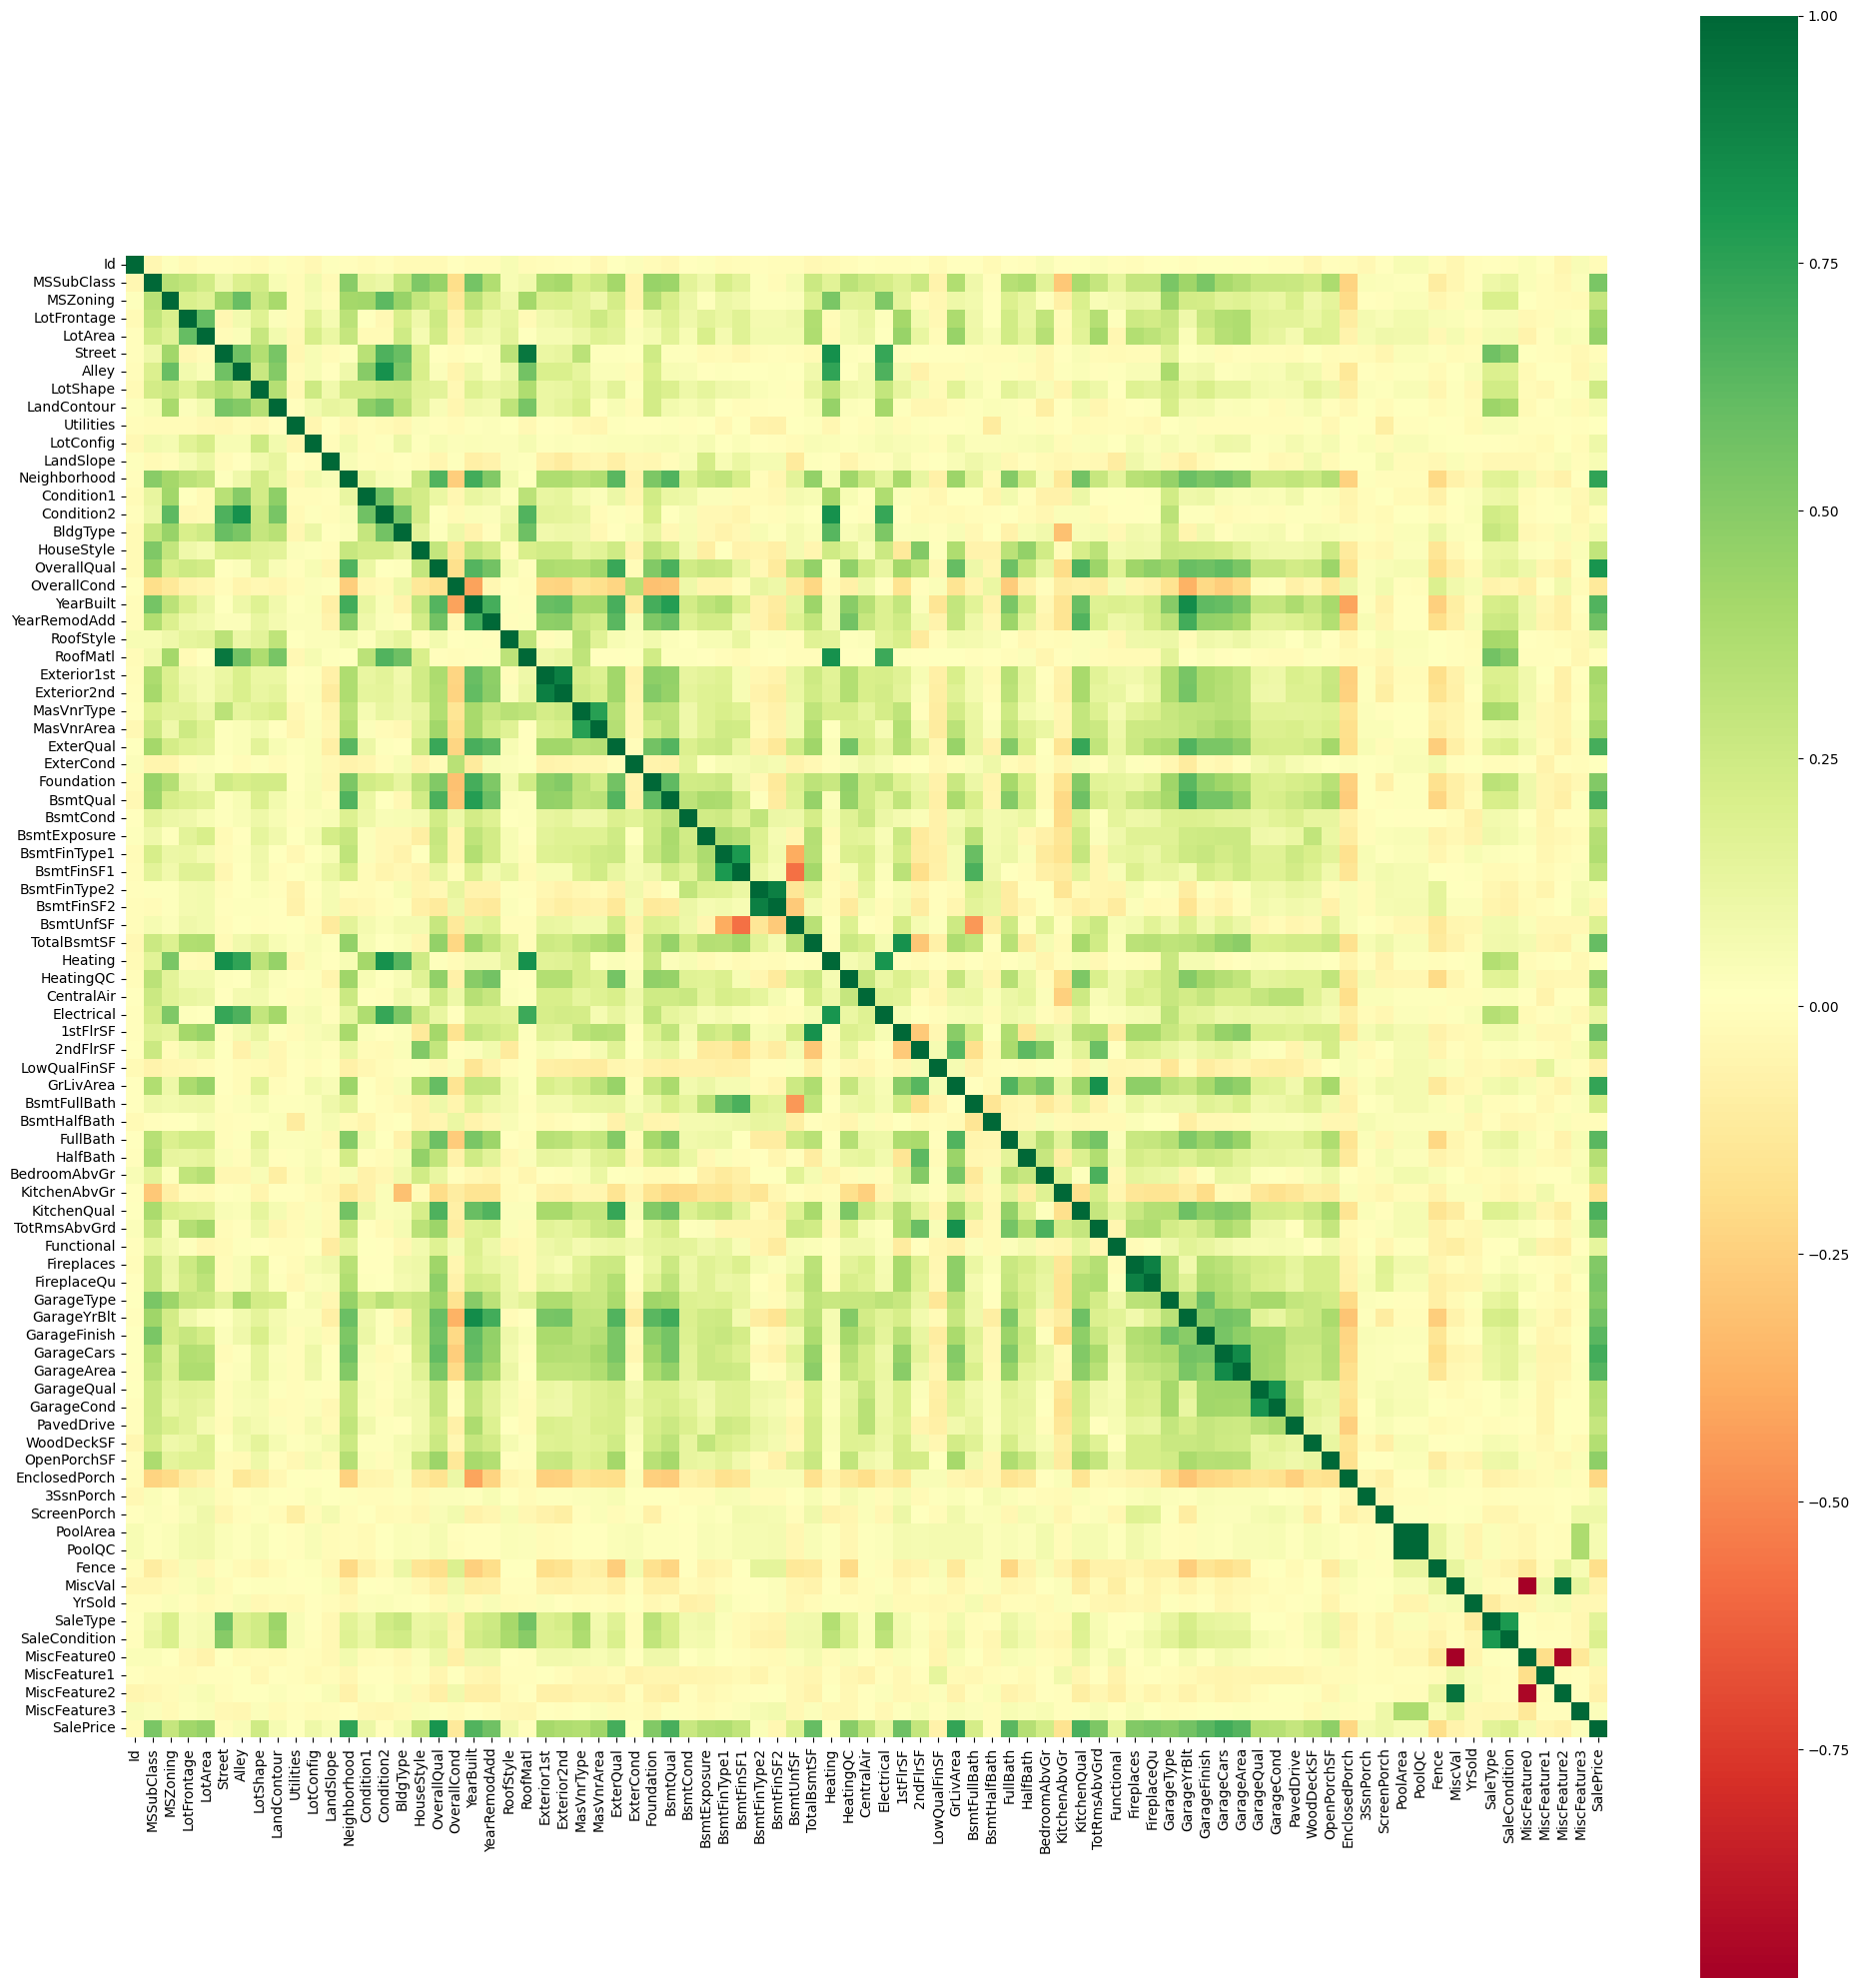

In [15]:
corrdf = train_ff.corr(method='spearman')
fig, ax = plt.subplots(1, 1, figsize=(20, 20), layout='tight')
sns.heatmap(data=corrdf, annot=False, fmt='.1g', square=True, cmap='RdYlGn', ax=ax)  #palette='RdYlGn', 

In [16]:
# Drop some variables after correlation analysis
train_clean = train_ff.drop(columns=['PoolQC', 'FireplaceQu', 'GarageCars'])

In [17]:
X, y = train_clean.drop(columns=['SalePrice']), train_clean['SalePrice']

In [22]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error, mean_squared_log_error, mean_absolute_error, r2_score, make_scorer

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=0xC0FFEE)

model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0xC0FFEE,
    verbosity=0
    )

scoring = {
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'r2': make_scorer(r2_score)
}

cv_results = cross_validate(model, X, y, cv=kf, scoring=scoring, return_train_score=True)

print(cv_results)

print("=" * 70)
print("CROSS-VALIDATION RESULTS")
print("=" * 70)

# MSE Results
mse_train = -cv_results['train_neg_mse']
mse_val = -cv_results['test_neg_mse']
rmse_train = np.sqrt(mse_train)
rmse_val = np.sqrt(mse_val)

print("\nMean Squared Error (MSE):")
print(f"  Training: {mse_train.mean():.2f} (+/- {mse_train.std():.2f})")
print(f"  Validation: {mse_val.mean():.2f} (+/- {mse_val.std():.2f})")

print("\nRoot Mean Squared Error (RMSE):")
print(f"  Training: {rmse_train.mean():.2f} (+/- {rmse_train.std():.2f})")
print(f"  Validation: {rmse_val.mean():.2f} (+/- {rmse_val.std():.2f})")

# MAE Results
mae_train = -cv_results['train_neg_mae']
mae_val = -cv_results['test_neg_mae']

print("\nMean Absolute Error (MAE):")
print(f"  Training: {mae_train.mean():.2f} (+/- {mae_train.std():.2f})")
print(f"  Validation: {mae_val.mean():.2f} (+/- {mae_val.std():.2f})")

# R² Results
r2_train = cv_results['train_r2']
r2_val = cv_results['test_r2']

print("\nR² Score:")
print(f"  Training: {r2_train.mean():.4f} (+/- {r2_train.std():.4f})")
print(f"  Validation: {r2_val.mean():.4f} (+/- {r2_val.std():.4f})")

print("\nPer-fold breakdown:")
for i in range(kf.n_splits):
    print(f"  Fold {i+1}: RMSE={rmse_val[i]:.2f}, MAE={mae_val[i]:.2f}, R²={r2_val[i]:.4f}")

print("=" * 70)

{'fit_time': array([0.34175301, 0.29255819, 0.46860909, 0.41609359, 0.33964801,
       0.31938314, 0.32640862, 0.32003117, 0.32501006, 0.37340236]), 'score_time': array([0.0118742 , 0.01165891, 0.01491618, 0.0125401 , 0.0120163 ,
       0.01323986, 0.01338601, 0.01246071, 0.01296377, 0.01375699]), 'test_neg_mse': array([-4.99733984e+08, -7.30600576e+08, -7.06415936e+08, -4.79167136e+08,
       -6.78803008e+08, -4.17856736e+08, -8.40339456e+08, -6.97872192e+08,
       -7.48890560e+08, -1.10666266e+09]), 'train_neg_mse': array([-25411318., -24969520., -27376840., -25298546., -21467928.,
       -25037564., -27343630., -24408104., -22433590., -24582490.]), 'test_neg_mae': array([-15265.62304688, -17350.90039062, -16775.11914062, -14407.72949219,
       -15119.71582031, -13994.09570312, -16837.77734375, -15989.93847656,
       -16873.98632812, -17549.55859375]), 'train_neg_mae': array([-3826.02050781, -3813.95361328, -4021.54907227, -3821.13867188,
       -3526.18847656, -3805.47607422, -39